In [1]:
"""
2D implementation of 
∂t phi_a= ∂x [D ∂x phi_a + phi_a(1-phi_a-phi_b)∂x pi_a +  sqrt(2D phi_a(1-phi_a-phi_b)) Z]
∂t phi_b= ∂x [D ∂x phi_b + phi_b(1-phi_a-phi_b)∂x pi_b +  sqrt(2D phi_b(1-phi_a-phi_b)) Z]
using a conservative finite-volume discretization and a stochastic (predictor-corrector) time integrator.

Features:
- Positivity floor for density
- multiplicative conservative noise (phi_a(1-ph i_a-phi_b))
- Can be extended to the case with convolutional interaction potential using FFT (periodic)

Author: Tuan Pham and Wout Merbis
"""
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import fhd
import importlib
import time

importlib.reload(fhd)


import os
os.environ["NUMBA_THREADING_LAYER"] = "omp"

import numba as nb


# Test runs

In [2]:
N = (2**7, 2**7)
L = (50,50)
Lx, Ly = L
sim_2d = fhd.fhd_2d(L,N, bc= 'Neumann', fft=False, schelling_flux="finite_volume",projection_mode="redistribute" , use_numba_projection=True, numba_projection_threads=4)
sim_2d.set_seed(1234)


/home/wmrs@cbsp.nl/codebase/fluctuating_hydro/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [5]:
Ta = 2/5
Tb = 2/5
kappa_aa = 0.6
kappa_bb = 0.6
kappa_ab = -0.4
kappa_ba = -0.4

regimes = ["segregating", "integrating", "migrating", "well-mixed"]
kappas = [np.array([[0.6, -0.4],[-0.4, 0.6]]), np.array([[0.6, 1], [1, 0.6]]),
np.array([[1, 1], [-1, 1]]), np.array([[0, 0], [0, 0]])]


# nu = np.zeros((2,2,2))
h = 0.01
# coupling matrix kappa  for pi^{(a)} = sum_b kappa_ab * (V * phi_b)
kappa = np.array([[kappa_aa, kappa_ab],
                  [kappa_ba, kappa_bb]])
# kappa = np.array([[0,0],[0,0]])
D = 0.*np.ones(2) # Schelling diffusion coefficient
Gamma = np.eye(2) # Utility nabla^3 term coefficient
D_v = 0.1 #Voter model diffusion term
beta = 10

param = {'D': D, 'kappa': kappas[3], 'Gamma': Gamma, 'D_v': D_v, 'beta': beta, 'h' : h}

x = sim_2d.x
y = sim_2d.y

xx, yy = np.meshgrid(x, y, indexing='ij')
nspecies = sim_2d.nspecies

np.random.default_rng(1234)

phi = np.zeros((nspecies,)+ sim_2d.N)
phi0 = 0.35
pert_amp = 0.0
noise_amp = 0.01
# phi[0] = phi0 + pert_amp * np.cos(2*np.pi*(xx +yy) / Lx * 2) + 0.05 * np.random.normal(size=sim_2d.N) 
phi[0] = phi0 + pert_amp * np.cos(2*np.pi*(xx+ 2*yy) / Lx * 2)  + pert_amp * np.cos(2*np.pi*(yy) / Lx * 2)  + noise_amp * np.random.normal(size=sim_2d.N) 
#phi0 + pert_amp * np.cos(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x+L//8)**2/(2*(L//12)**2)) 
#  0.5*(np.tanh(-x)+1)/2
# phi[1] = phi0 + pert_amp * np.sin(2*np.pi*(xx - yy) / Lx * 2) + 0.05 * np.random.normal(size=sim_2d.N) 
phi[1] = phi0 + pert_amp * np.sin(2*np.pi*(xx+ 2*yy) / Lx * 2)  + pert_amp * np.sin(2*np.pi*(yy) / Lx * 2) + noise_amp * np.random.normal(size=sim_2d.N) 
#phi0 + pert_amp * np.sin(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x-L//8)**2/(2*(L//12)**2)) 
# 0.5*(np.tanh(x)+1)/2

# phi = np.load(f"data/runs/run_T04_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")[:,-1,:,:]

Step 500/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.725506, mean_kl_div = 0.232017
Step 1000/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.751493, mean_kl_div = 0.248596
Step 1500/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.759525, mean_kl_div = 0.255644
Step 2000/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.768956, mean_kl_div = 0.261338
Step 2500/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.773170, mean_kl_div = 0.264366
Step 3000/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.776747, mean_kl_div = 0.266533
Step 3500/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.775862, mean_kl_div = 0.266540
Step 4000/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.781044, mean_kl_div = 0.269583
Step 4500/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.784026, mean_kl_div = 0.272506
Step 5000/200000: mean rho = 0.349998, min = 0.000000e+00, D_index = 0.785816, mean

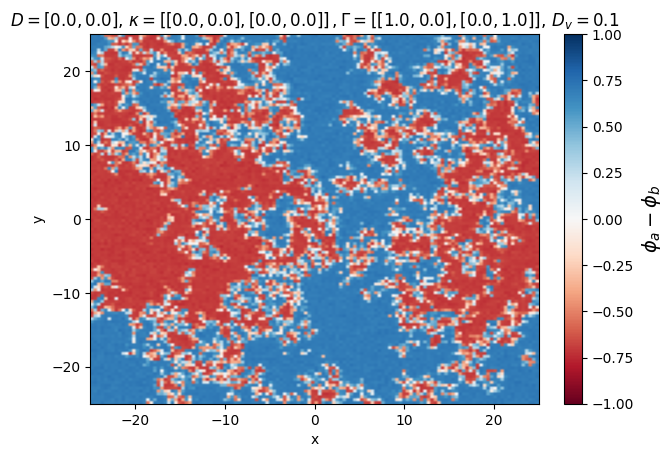

Simulation ran in t = 465.994626 seconds


In [6]:
dt = 2e-3
nsteps = 200_000
noise = True
frames = 400

# param["D_v"] = 0.04
# phi = phi_run[:,-1,:,:].copy()


st = time.time()
phi_run = sim_2d.run(phi, param, nsteps, dt, noise, frames, scheme = "FE", model = "Voter")
# phi_run = sim_2d.run_until_converged(phi, param, dt, noise, T=200, K=100, scheme = 'FE', model = "Schelling+Voter")
et = time.time()
print(f"Simulation ran in t = {et-st:.6f} seconds")

In [ ]:
phi_run

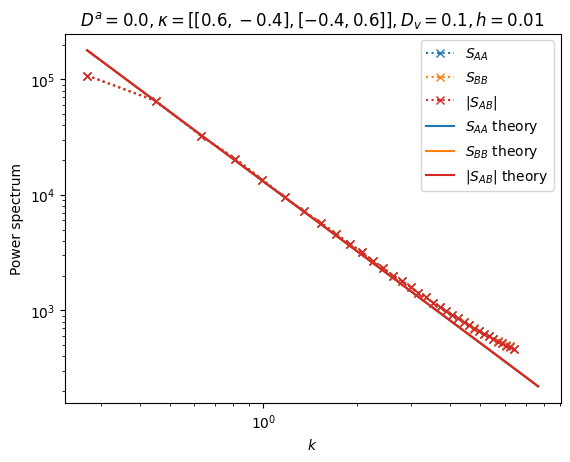

In [8]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from structure_factor import *

def fit_amplitude_logspace(theory, data):
    """
    Fit a multiplicative amplitude amp in log-space:
        log(data) ~ log(amp) + log(theory)
    """
    valid = (
        np.isfinite(theory) & np.isfinite(data) &
        (theory > 0) & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    log_amp = np.mean(np.log(data[valid]) - np.log(theory[valid]))
    return np.exp(log_amp)


averaging_bp = 1
k_bins, power_spectra, G_AB = fhd.power_spectrum(phi_run, sim_2d.L, num_bins= 64, bp = averaging_bp, centered = True)
# param['h'] = 0.01

S_AA_theory = np.zeros(len(k_bins))
S_AB_theory = np.zeros(len(k_bins))
S_BB_theory = np.zeros(len(k_bins))

param2 = param.copy()
param2["D"] = np.ones(2)*1e-5
for i, k in enumerate(k_bins):
    structure_factors = structure_factor(k,phi_run[0,averaging_bp:,:].mean(), phi_run[1,averaging_bp:,:].mean(), param2)
    S_AA_theory[i] = structure_factors[0,0]
    S_AB_theory[i] = structure_factors[0,1]
    S_BB_theory[i] = structure_factors[1,1]


k_interp = np.linspace(k_bins.min(), k_bins.max(), 1000)  # 1000 points for smooth interpolation
interpolate_func = interp1d(k_bins, power_spectra[0], kind='cubic', fill_value="extrapolate")
SAA_interp = interpolate_func(k_interp)

# Find the k value where the spectrum is maximal
k_max_AA = k_interp[np.argmax(SAA_interp)]

# Maximal wavenumber of annular Brillouin zone
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = k_bins <= 0.8*K_cut

amp = 4e5
theory_bp = 5
theory_ep = -20
k_bins_thy = k_bins[mask][theory_bp: ]

def std_amp(amp, theory, data):
    AA = np.abs(amp*theory[0] - data[0])
    BB = np.abs(amp*theory[1] - data[1])
    AB = np.abs(amp*theory[2] - data[2])
    return np.std(np.array([AA,BB,AB]))

theory = np.array([S_AA_theory[theory_bp:theory_ep], S_BB_theory[theory_bp:theory_ep], np.abs(S_AB_theory[theory_bp:theory_ep])])
data = np.array([power_spectra[0,theory_bp:theory_ep],power_spectra[1,theory_bp:theory_ep], np.abs(G_AB[theory_bp:theory_ep])])
optamp = minimize(std_amp, amp, args = (theory, data))

# dk = k_bins[1]-k_bins[0]

amp=fit_amplitude_logspace(theory, data)
amp = optamp.x

plt.plot(k_bins[mask][1:], power_spectra[0,mask][1:], "x:", label = r"$S_{AA}$", color = 'tab:blue')
# plt.plot(k_max_AA, interpolate_func(k_max_AA), marker = "*", color = 'k')
plt.plot(k_bins[mask][1:], power_spectra[1,mask][1:], "x:", label = r"$S_{BB}$", color = 'tab:orange')
# plt.plot(k_bins[mask][1:], power_spectra[2,mask][1:], "x:", label = r"$S_{00}$", color = 'tab:green')
plt.plot(k_bins[mask][1:], np.abs(G_AB)[mask][1:], "x:", label = r"$|S_{AB}|$", color = 'tab:red')
plt.plot(k_bins[S_AA_theory>0][1:theory_ep], amp*S_AA_theory[S_AA_theory>0][1:theory_ep], '-', label = r"$S_{AA}$ theory",  color = 'tab:blue')
plt.plot(k_bins[S_BB_theory>0][1:theory_ep], amp*S_BB_theory[S_BB_theory>0][1:theory_ep], '-', label = r"$S_{BB}$ theory", color = 'tab:orange')
plt.plot(k_bins[S_AB_theory<0][1:theory_ep], amp*np.abs(S_AB_theory[S_AB_theory<0])[1:theory_ep], '-', label = r"$|S_{AB}|$ theory", color = 'tab:red')
plt.title(fr"$D^a = {param['D'][0]},  \kappa = [[{kappa[0,0]},{kappa[0,1]}],[{kappa[1,0]}, {kappa[1,1]}]] , D_v = {param['D_v']}, h = {param['h']:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k$")
plt.ylabel(r"Power spectrum")
plt.legend()
plt.tight_layout
plt.show()

In [9]:
# Projection diagnostics for redistribution run
sim_2d.print_projection_diagnostics()

Projection diagnostics
----------------------
calls:                 0
low entries:           0
mass added low:        0.00000000e+00
max low violation:     0.00000000e+00
high entries:          0
mass removed high:     0.00000000e+00
max high violation:    0.00000000e+00
simplex cells:         0
mass removed simplex:  0.00000000e+00
max simplex violation: 0.00000000e+00
net mass change:       0.00000000e+00
expected net change:   0.00000000e+00
bookkeeping error:     0.00000000e+00
mass transferred low:  0.00000000e+00
mass transferred AtoB: 0.00000000e+00
mass transferred BtoA: 0.00000000e+00
transfer fallback n:   0
transfer fallback add: 0.00000000e+00
redis low local:       0.00000000e+00
redis low global:      0.00000000e+00
redis high local:      0.00000000e+00
redis high global:     0.00000000e+00
redis simplex local:   0.00000000e+00
redis simplex global:  0.00000000e+00
redis low leftover:    0.00000000e+00
redis high leftover:   0.00000000e+00
redis simplex leftover:0.000000

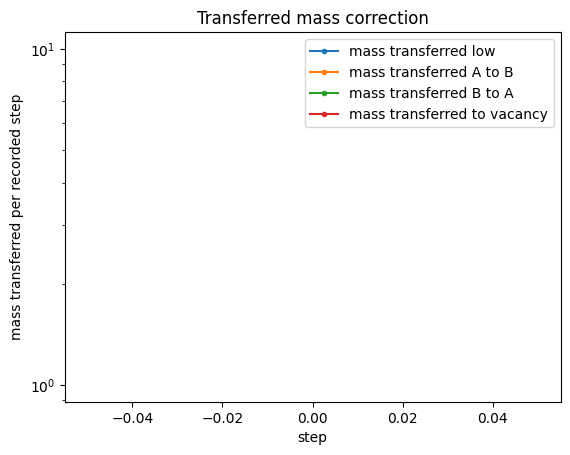

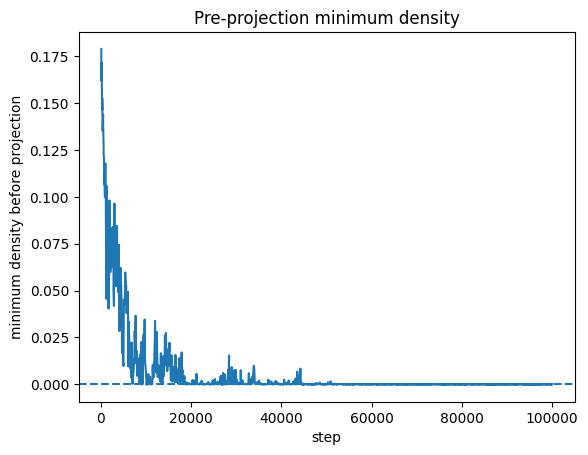

In [22]:
hist = sim_2d.projection_history_as_dict()

steps = hist["step"]

mass_transferred_low = hist['mass_transferred_low']
mass_transferred_AtoB = hist['mass_transferred_AtoB']
mass_transferred_BtoA = hist['mass_transferred_BtoA']
mass_transferred_vacancy = hist['mass_transferred_to_vacancy']
mass_added = hist["mass_added_low"]
mass_removed = hist["mass_removed_simplex"]
min_pre = hist["min_pre_projection"]

# Plot only positive clipping events on log scale
mask = mass_transferred_low > 0.0

plt.figure()
plt.plot(steps[mask], mass_transferred_low[mask], ".-", label = 'mass transferred low')
plt.plot(steps[mask], mass_transferred_AtoB[mask], ".-", label = 'mass transferred A to B')
plt.plot(steps[mask], mass_transferred_BtoA[mask], ".-", label = 'mass transferred B to A')
plt.plot(steps[mask], mass_transferred_vacancy[mask], ".-", label = 'mass transferred to vacancy')
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("mass transferred per recorded step")
plt.title("Transferred mass correction")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps, min_pre)
plt.axhline(0.0, linestyle="--")
plt.xlabel("step")
plt.ylabel("minimum density before projection")
plt.title("Pre-projection minimum density")
plt.show()

In [10]:
hist = sim_2d.projection_history_as_dict()

steps = hist["step"]
mass_redis_low = hist["mass_redistributed_low_local"]/128**2
mass_redis_low_global = hist["mass_redistributed_low_global"]/128**2
mass_redis_simplex = hist["mass_redistributed_simplex_local"]/128**2
mass_redis_simplex_global = hist["mass_redistributed_simplex_global"]/128**2
min_pre = hist["min_pre_projection"]

# Plot only positive clipping events on log scale
# mask = mass_removed > 0.0

plt.figure()
plt.plot(steps, mass_redis_low, ".-", label = "redistributed low")
plt.plot(steps, mass_redis_low_global, ".-", label = "redistributed low global")
plt.plot(steps, mass_redis_simplex, ".-", label = "redistributed simplex")
plt.plot(steps, mass_redis_simplex_global, ".-", label = "redistributed simplex global")
plt.yscale("log")
# plt.xscale("log")
plt.xlabel("step")
plt.ylabel("mass redistributed per recorded step")
plt.title("Redistribute mass correcting projection method")
plt.legend()
plt.show()

mask = mass_redis_low > 0.0
# plt.figure()
# plt.plot(steps[mask], mass_added[mask], ".-")
# plt.yscale("log")
# plt.xlabel("step")
# plt.ylabel("mass added by low threshold clipping per recorded step")
# plt.title("Low-clipping mass correction")
# plt.show()

plt.figure()
plt.plot(steps[mask], min_pre[mask])
plt.axhline(0.0, linestyle="--")
plt.xlabel("step")
# plt.yscale('log')
plt.ylabel("minimum density before projection")
plt.title("Pre-projection minimum density")
plt.show()

KeyError: 'step'

In [21]:
import cProfile, pstats

prof = cProfile.Profile()
prof.enable()

dt = 5e-4
nsteps = 10_000
noise = True
frames = 100

run_clip = np.load(f"data/runs/run_T04_Neumann_clip_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")
 
phi = run_clip[:,-1,:,:]
phi_run = sim_2d.run(
    phi, param, nsteps, dt, noise, frames,
    model="Schelling+Voter",
    verbatum=False,
)

prof.disable()
stats = pstats.Stats(prof).sort_stats("cumtime")
stats.print_stats(30)

         70471944 function calls (70471934 primitive calls) in 122.338 seconds

   Ordered by: cumulative time
   List reduced from 141 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        8    0.000    0.000  122.338   15.292 /home/wmrs@cbsp.nl/codebase/fluctuating_hydro/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        8    0.000    0.000  122.338   15.292 {built-in method builtins.exec}
        1    0.092    0.092  122.251  122.251 /home/wmrs@cbsp.nl/codebase/fluctuating_hydro/fhd/FHD_2D.py:1830(run)
    10000    0.478    0.000  122.116    0.012 /home/wmrs@cbsp.nl/codebase/fluctuating_hydro/fhd/FHD_2D.py:1792(step)
    10000    0.900    0.000   83.628    0.008 /home/wmrs@cbsp.nl/codebase/fluctuating_hydro/fhd/FHD_2D.py:984(project_density)
    10000    8.470    0.001   81.286    0.008 /home/wmrs@cbsp.nl/codebase/fluctuating_hydro/fhd/FHD_2D.py:491(_project_density_redistribute)
  24572

In [7]:
dt = 1e-3
nsteps = 2_000_000
noise = True
frames = 800
phi_run = np.load(f"data/runs/run_migrating_Neumann_redistribute_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")

In [125]:
np.save(f"data/runs/run_segregating_hybrid_projection_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy", phi_run)

In [15]:
run_clip = np.load(f"data/runs/run_T04_Neumann_clip_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")
run_transfer = np.load(f"data/runs/run_T04_Neumann_transfer_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")
run_det = np.load(f"data/runs/run_T04_Neumann_det_D{D[0]:.2f}_Dv{D_v:.2f}.npy")
run_redistribute = np.load(f"data/runs/run_T04_Neumann_redistribute_D{D[0]:.2f}_Dv{D_v:.2f}_noise.npy")

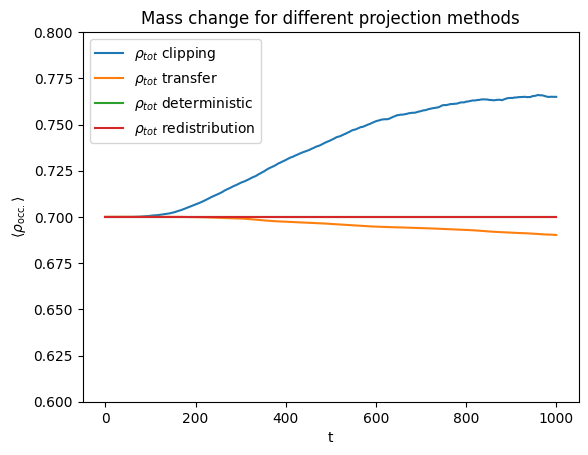

In [16]:
# dt = 5e-4
nsteps = 1_000_000
frames = 400
t = np.linspace(0, dt*nsteps, frames+1)

plt.plot(t,run_clip.sum(axis=0).mean(axis=(1,2)), label = r"$\rho_{tot}$ clipping")
plt.plot(t,run_transfer.sum(axis=0).mean(axis=(1,2)), label = r"$\rho_{tot}$ transfer")
plt.plot(t,run_det.sum(axis=0).mean(axis=(1,2)), label = r"$\rho_{tot}$ deterministic")
# plt.hlines(0.7, 0, dt*nsteps, color='r', linestyles="--")
plt.plot(t,run_redistribute.sum(axis=0).mean(axis=(1,2)), label = r"$\rho_{tot}$ redistribution")
plt.xlabel("t")
plt.ylim([0.6,0.8])
plt.ylabel(r"$\langle \rho_{\rm occ.} \rangle$")
plt.title("Mass change for different projection methods")
plt.legend()
plt.show()

In [17]:
print(f"Clipping mass change = {run_clip.sum(axis=0).mean(axis=(1,2))[-1] - run_clip.sum(axis=0).mean(axis=(1,2))[0]}")
print(f"Tranfer_to_other mass change = {run_transfer.sum(axis=0).mean(axis=(1,2))[-1] - run_transfer.sum(axis=0).mean(axis=(1,2))[0]}")
print(f"Redistribute mass change = {run_redistribute.sum(axis=0).mean(axis=(1,2))[-1] - run_redistribute.sum(axis=0).mean(axis=(1,2))[0]}")
print(f"Det mass change = {run_det.sum(axis=0).mean(axis=(1,2))[-1] - run_det.sum(axis=0).mean(axis=(1,2))[0]}")

Clipping mass change = 0.0650269381074029
Tranfer_to_other mass change = -0.009820439922441082
Redistribute mass change = -1.5987211554602254e-14
Det mass change = 3.1086244689504383e-15


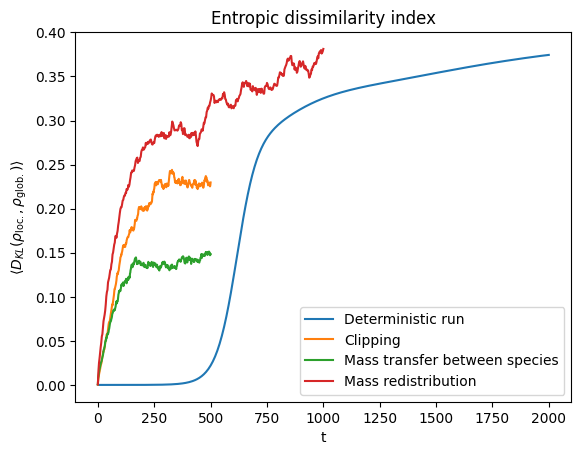

In [18]:
frames = run_clip.shape[1]-1

KL_div_clip = np.array([fhd.mean_relative_entropy(run_clip[:,t,:]) for t in range(frames+1)])
KL_div_transfer = np.array([fhd.mean_relative_entropy(run_transfer[:,t,:]) for t in range(frames+1)])
KL_div_det = np.array([fhd.mean_relative_entropy(run_det[:,t,:]) for t in range(frames+1)])
KL_div_redistribute = np.array([fhd.mean_relative_entropy(run_redistribute[:,t,:]) for t in range(frames+1)])

t = np.linspace(0, dt*nsteps, frames+1)
t_noise = np.linspace(0, 5e-4*nsteps, frames+1)
t_det = np.linspace(0, 2e-3*nsteps, frames+1)


plt.plot(t_det,KL_div_det,  label = "Deterministic run")

plt.plot(t_noise,KL_div_clip, label = "Clipping")
plt.plot(t_noise,KL_div_transfer,  label = "Mass transfer between species")
plt.plot(t,KL_div_redistribute, label = "Mass redistribution")
# plt.yscale('log')
plt.xlabel("t")
plt.ylabel(r"$\langle D_{KL}(\rho_{\rm loc.}, \rho_{\rm glob.}) \rangle$")
plt.title("Entropic dissimilarity index")
# plt.xscale("log")
plt.legend()
plt.show()

In [20]:
print(f"Clipping final index = {KL_div_clip[-1]}")
print(f"tranfer_to_other final index = {KL_div_transfer[-1]}")
print(f"redistribute final index = {KL_div_redistribute[-1]}")
print(f"Deterministic final index = {KL_div_det[-1]}")

Clipping final index = 0.22973791562599288
tranfer_to_other final index = 0.14846412708565823
redistribute final index = 0.38125788214541234
Deterministic final index = 0.37445697359580726


## Empirical growth rates

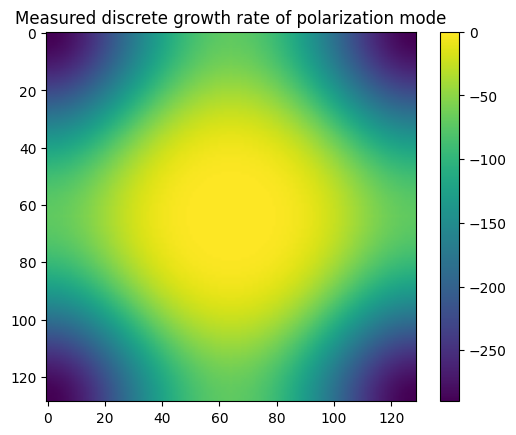

In [5]:
Nx, Ny = sim_2d.N
growth = np.zeros((Nx, Ny))


for mx in range(Nx):
    for my in range(Ny):
        if mx == 0 and my == 0:
            continue
        growth[mx, my] = fhd.measure_mode_growth(sim_2d, 0.35, param, mx, my)

plt.imshow(np.fft.fftshift(growth))
plt.colorbar()
plt.title("Measured discrete growth rate of polarization mode")
plt.show()

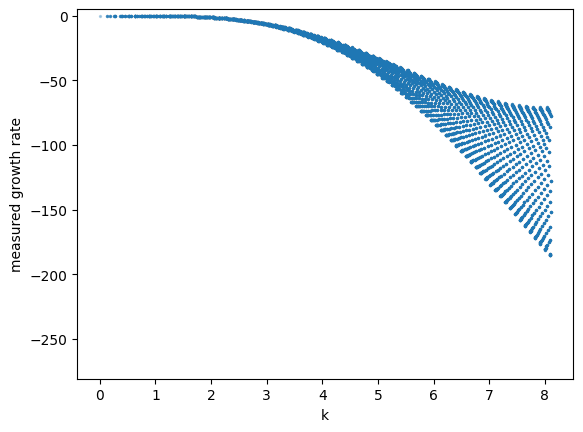

In [6]:
kx = np.fft.fftfreq(Nx, d=sim_2d.dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=sim_2d.dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky, indexing="ij")
K = np.sqrt(KX**2 + KY**2)
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = K <= K_cut

plt.scatter(K[mask].ravel(), growth[mask].ravel(), s=2, alpha=0.3)
plt.xlabel("k")
plt.ylabel("measured growth rate")
plt.ylim(np.percentile(growth, 1), 5)
plt.show()

In [7]:
def radial_mode_counts(sim, nbins=75):
    Nx, Ny = sim.N
    dx, dy = sim.dx, sim.dy

    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    k_nyquist = min(np.pi / dx, np.pi / dy)
    mask = (K > 0) & (K <= k_nyquist)

    bins = np.linspace(0.0, k_nyquist, nbins + 1)
    bin_id = np.digitize(K[mask].ravel(), bins) - 1

    counts = np.array([
        np.count_nonzero(bin_id == b)
        for b in range(nbins)
    ])

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, counts

In [8]:
radial_mode_counts(sim_2d)

(array([0.05403539, 0.16210618, 0.27017697, 0.37824776, 0.48631854,
        0.59438933, 0.70246012, 0.8105309 , 0.91860169, 1.02667248,
        1.13474327, 1.24281405, 1.35088484, 1.45895563, 1.56702642,
        1.6750972 , 1.78316799, 1.89123878, 1.99930956, 2.10738035,
        2.21545114, 2.32352193, 2.43159271, 2.5396635 , 2.64773429,
        2.75580508, 2.86387586, 2.97194665, 3.08001744, 3.18808822,
        3.29615901, 3.4042298 , 3.51230059, 3.62037137, 3.72844216,
        3.83651295, 3.94458374, 4.05265452, 4.16072531, 4.2687961 ,
        4.37686688, 4.48493767, 4.59300846, 4.70107925, 4.80915003,
        4.91722082, 5.02529161, 5.1333624 , 5.24143318, 5.34950397,
        5.45757476, 5.56564555, 5.67371633, 5.78178712, 5.88985791,
        5.99792869, 6.10599948, 6.21407027, 6.32214106, 6.43021184,
        6.53828263, 6.64635342, 6.75442421, 6.86249499, 6.97056578,
        7.07863657, 7.18670735, 7.29477814, 7.40284893, 7.51091972,
        7.6189905 , 7.72706129, 7.83513208, 7.94

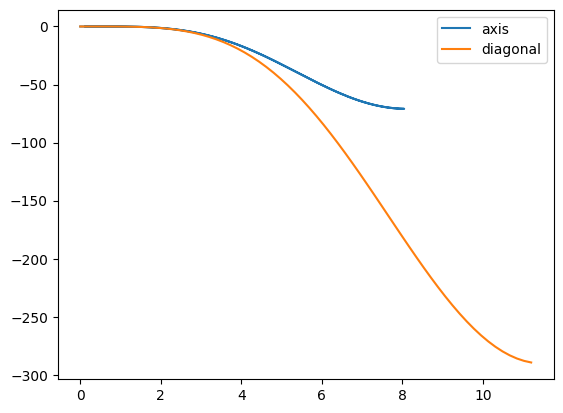

In [25]:
# axis direction: ky = 0
S_axis = growth[:, 0]
k_axis = K[:,0]

# diagonal direction: kx = ky
S_diag = np.array([growth[i, i] for i in range(Nx // 2)])
k_diag = np.array([K[i, i] for i in range(Nx // 2)])

plt.plot(k_axis, S_axis, label="axis")
plt.plot(k_diag, S_diag, label="diagonal")
# plt.ylim([1e-10,2e-2])
plt.legend()

In [ ]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from structure_factor import *

averaging_bp = -100
k_bins, power_spectra, G_AB = fhd.power_spectrum(phi_run, sim_2d.L, num_bins= 60, bp = averaging_bp, centered = True)
# param['h'] = h

S_AA_theory = np.zeros(len(k_bins))
S_AB_theory = np.zeros(len(k_bins))
S_BB_theory = np.zeros(len(k_bins))

for i, k in enumerate(k_bins):
    structure_factors = structure_factor(k,phi_run[0,averaging_bp:,:].mean(), phi_run[1,averaging_bp:,:].mean(), param)
    S_AA_theory[i] = structure_factors[0,0]
    S_AB_theory[i] = structure_factors[0,1]
    S_BB_theory[i] = structure_factors[1,1]


k_interp = np.linspace(k_bins.min(), k_bins.max(), 1000)  # 1000 points for smooth interpolation
interpolate_func = interp1d(k_bins, power_spectra[0], kind='cubic', fill_value="extrapolate")
SAA_interp = interpolate_func(k_interp)

# Find the k value where the spectrum is maximal
k_max_AA = k_interp[np.argmax(SAA_interp)]

# Maximal wavenumber of annular Brillouin zone
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = k_bins <= K_cut

amp = 4000
theory_bp = 9
theory_ep = -25
k_bins_thy = k_bins[mask][theory_bp: ]

def std_amp(amp, theory, data):
    AA = np.abs(amp*theory[0] - data[0])
    BB = np.abs(amp*theory[1] - data[1])
    AB = np.abs(amp*theory[2] - data[2])
    return np.std(np.array([AA,BB,AB]))

theory = np.array([S_AA_theory[theory_bp:theory_ep], S_BB_theory[theory_bp:theory_ep], np.abs(S_AB_theory[theory_bp:theory_ep])])
data = np.array([power_spectra[0,theory_bp:theory_ep],power_spectra[1,theory_bp:theory_ep], np.abs(G_AB[theory_bp:theory_ep])])
optamp = minimize(std_amp, amp, args = (theory, data))

# dk = k_bins[1]-k_bins[0]

amp=optamp.x



plt.plot(k_bins[mask][1:], power_spectra[0,mask][1:], "x:", label = r"$S_{AA}$", color = 'tab:blue')
# plt.plot(k_max_AA, interpolate_func(k_max_AA), marker = "*", color = 'k')
plt.plot(k_bins[mask][1:], power_spectra[1,mask][1:], "x:", label = r"$S_{BB}$", color = 'tab:orange')
plt.plot(k_bins[mask][1:], power_spectra[2,mask][1:], "x:", label = r"$S_{00}$", color = 'tab:green')
plt.plot(k_bins[mask][1:], np.abs(G_AB)[mask][1:], "x:", label = r"$|S_{AB}|$", color = 'tab:red')
plt.plot(k_bins[S_AA_theory>0][1:theory_ep], amp*S_AA_theory[S_AA_theory>0][1:theory_ep], '-', label = r"$S_{AA}$ theory",  color = 'tab:blue')
plt.plot(k_bins[S_BB_theory>0][1:theory_ep], amp*S_BB_theory[S_BB_theory>0][1:theory_ep], '-', label = r"$S_{BB}$ theory", color = 'tab:orange')
plt.plot(k_bins[S_AB_theory<0][1:theory_ep], amp*np.abs(S_AB_theory[S_AB_theory<0])[1:theory_ep], '-', label = r"$|S_{AB}|$ theory", color = 'tab:red')
plt.title(fr"$D^a = {param['D'][0]},  \kappa = [[{kappa[0,0]},{kappa[0,1]}],[{kappa[1,0]}, {kappa[1,1]}]] , D_v = {param['D_v']}, h = {param['h']:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k$")
plt.ylabel(r"Power spectrum")
plt.legend()
plt.tight_layout
plt.show()

NameError: name 'phi_run' is not defined

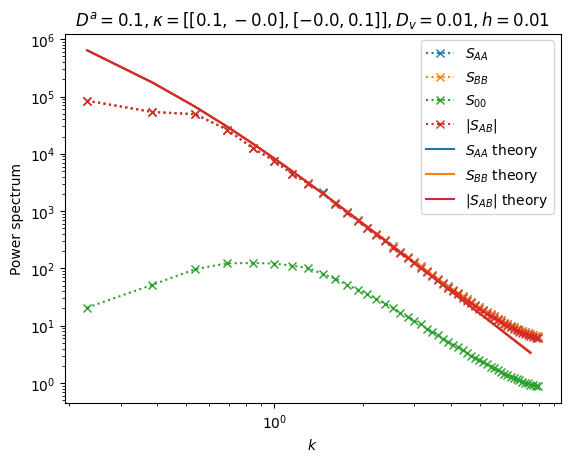

In [100]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from structure_factor import *

averaging_bp = -100
k_bins, power_spectra, G_AB = fhd.power_spectrum(phi_run, sim_2d.L, num_bins= 75, bp = averaging_bp, centered = True)
# param['h'] = h

S_AA_theory = np.zeros(len(k_bins))
S_AB_theory = np.zeros(len(k_bins))
S_BB_theory = np.zeros(len(k_bins))

for i, k in enumerate(k_bins):
    structure_factors = structure_factor(k,phi_run[0,averaging_bp:,:].mean(), phi_run[1,averaging_bp:,:].mean(), param)
    S_AA_theory[i] = structure_factors[0,0]
    S_AB_theory[i] = structure_factors[0,1]
    S_BB_theory[i] = structure_factors[1,1]


k_interp = np.linspace(k_bins.min(), k_bins.max(), 1000)  # 1000 points for smooth interpolation
interpolate_func = interp1d(k_bins, power_spectra[0], kind='cubic', fill_value="extrapolate")
SAA_interp = interpolate_func(k_interp)

# Find the k value where the spectrum is maximal
k_max_AA = k_interp[np.argmax(SAA_interp)]

# Maximal wavenumber of annular Brillouin zone
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = k_bins <= K_cut

amp = 4000
theory_bp = 9
theory_ep = -25
k_bins_thy = k_bins[mask][theory_bp: ]

def std_amp(amp, theory, data):
    AA = np.abs(amp*theory[0] - data[0])
    BB = np.abs(amp*theory[1] - data[1])
    AB = np.abs(amp*theory[2] - data[2])
    return np.std(np.array([AA,BB,AB]))

theory = np.array([S_AA_theory[theory_bp:theory_ep], S_BB_theory[theory_bp:theory_ep], np.abs(S_AB_theory[theory_bp:theory_ep])])
data = np.array([power_spectra[0,theory_bp:theory_ep],power_spectra[1,theory_bp:theory_ep], np.abs(G_AB[theory_bp:theory_ep])])
optamp = minimize(std_amp, amp, args = (theory, data))

# dk = k_bins[1]-k_bins[0]

amp=optamp.x



plt.plot(k_bins[mask][1:], power_spectra[0,mask][1:], "x:", label = r"$S_{AA}$", color = 'tab:blue')
# plt.plot(k_max_AA, interpolate_func(k_max_AA), marker = "*", color = 'k')
plt.plot(k_bins[mask][1:], power_spectra[1,mask][1:], "x:", label = r"$S_{BB}$", color = 'tab:orange')
plt.plot(k_bins[mask][1:], power_spectra[2,mask][1:], "x:", label = r"$S_{00}$", color = 'tab:green')
plt.plot(k_bins[mask][1:], np.abs(G_AB)[mask][1:], "x:", label = r"$|S_{AB}|$", color = 'tab:red')
plt.plot(k_bins[S_AA_theory>0][1:theory_ep], amp*S_AA_theory[S_AA_theory>0][1:theory_ep], '-', label = r"$S_{AA}$ theory",  color = 'tab:blue')
plt.plot(k_bins[S_BB_theory>0][1:theory_ep], amp*S_BB_theory[S_BB_theory>0][1:theory_ep], '-', label = r"$S_{BB}$ theory", color = 'tab:orange')
plt.plot(k_bins[S_AB_theory<0][1:theory_ep], amp*np.abs(S_AB_theory[S_AB_theory<0])[1:theory_ep], '-', label = r"$|S_{AB}|$ theory", color = 'tab:red')
plt.title(fr"$D^a = {param['D'][0]},  \kappa = [[{kappa[0,0]},{kappa[0,1]}],[{kappa[1,0]}, {kappa[1,1]}]] , D_v = {param['D_v']}, h = {param['h']:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k$")
plt.ylabel(r"Power spectrum")
plt.legend()
plt.tight_layout
plt.show()

# Plots


In [12]:
# # load a run:

regimes = ["segregating", "integrating", "migrating", "well-mixed"]
kappas = [np.array([[0.6, -0.4],[-0.4, 0.6]]), np.array([[0.6, 1], [1, 0.6]]),
np.array([[1, 1], [-1, 1]]), np.array([[0., 0.], [0., 0.]])]

reg_idx = 0

regime = regimes[reg_idx]
Dv = 0.01
n_run = 0

phi_run = np.load(f"data/{regime}/run_{n_run}_det_Dv{Dv:.2f}.npy")
# phi_run = run_redistribute
# dt = 0.002
# nsteps = 500*phi_run.shape[1]
frames = phi_run.shape[1]

nu = np.zeros((2,2,2))
D = 0.1*np.ones(2) # Schelling diffusion coefficient
Gamma = np.eye(2) # Utility nabla^3 term coefficient
beta = 10


param = {'D': D, 'kappa': kappas[reg_idx], 'Gamma': Gamma, 'D_v': Dv, 'beta': beta, 'h': 0.01}


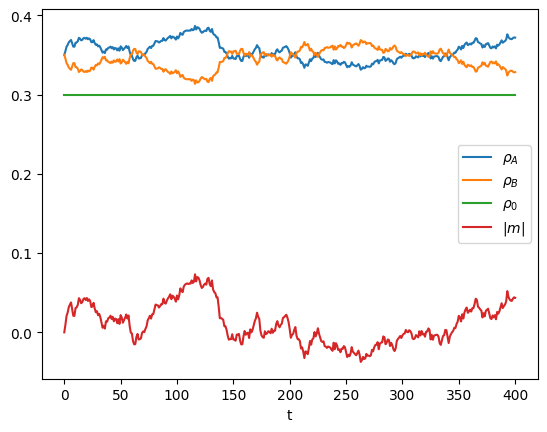

In [11]:

phi0_tot = np.mean(1- phi_run.sum(axis=0), axis = (1,2))
rhoA = phi_run[0].mean(axis=(1,2))
rhoB = phi_run[1].mean(axis=(1,2))
t = np.linspace(0, dt*nsteps, frames+1)

plt.plot(t,rhoA, label = r"$\rho_A$")
plt.plot(t,rhoB, label = r"$\rho_B$")
plt.plot(t,phi0_tot, label = r"$\rho_0$")
plt.plot(t,rhoA - rhoB, label = r"$|m|$")
plt.xlabel("t")
plt.legend()
plt.show()

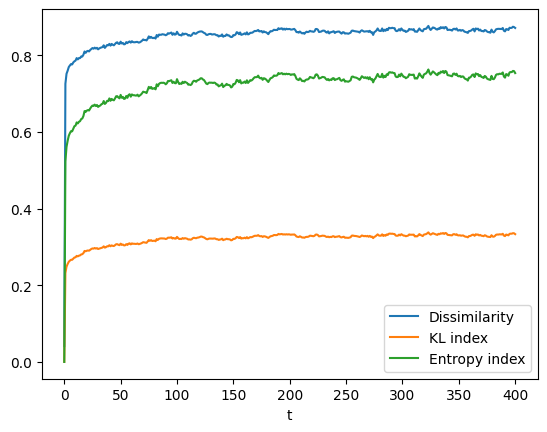

In [12]:
theta = Ta
frames = phi_run.shape[1]-1

Rel_ent = np.array([fhd.mean_relative_entropy(phi_run[:,t,:]) for t in range(frames+1)])
Dis_idx = np.array([fhd.dissimilarity(phi_run[:,t,:]) for t in range(frames+1)])
S_H = np.array([fhd.entropy_index(phi_run[:,t]) for t in range(frames + 1)])
Q_unhappy = np.array([fhd.fraction_unhappy(theta, phi_run[:,t]) for t in range(frames+1)])

t = np.linspace(0, dt*nsteps, frames+1)
plt.plot(t,Dis_idx, label = "Dissimilarity")
plt.plot(t,Rel_ent,  label = "KL index")
plt.plot(t,S_H, label = "Entropy index")
# plt.yscale('log')
plt.xlabel("t")
# plt.xscale("log")
plt.legend()
plt.show()

In [13]:
nsteps

200000

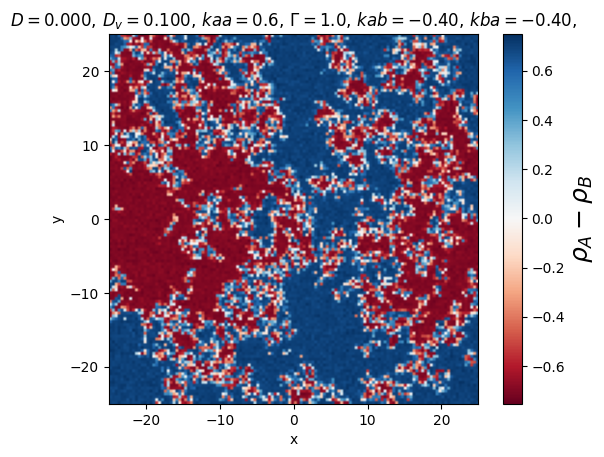

In [14]:
title = fr"$D = {D[0]:.3f},\, D_v = {D_v:.3f},\, kaa = {kappa_aa:.1f},\, \Gamma = { Gamma[0,0]},\, kab = {kappa_ab:.2f}, \, kba = {kappa_ba:.2f}, $"
phi_diff = phi_run[ 0] - phi_run[1]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi_diff[-1], cmap = 'RdBu', aspect='equal', origin='lower', extent=[-Lx/2,Lx/2,-Ly/2,Ly/2])
plt.title(title)
plt.xlabel("x")
plt.ylabel("y")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\rho_A - \rho_B$",size=18)
# plt.savefig("fhd_plots/integrating_tanh_noisy_reactions.pdf")
plt.show()

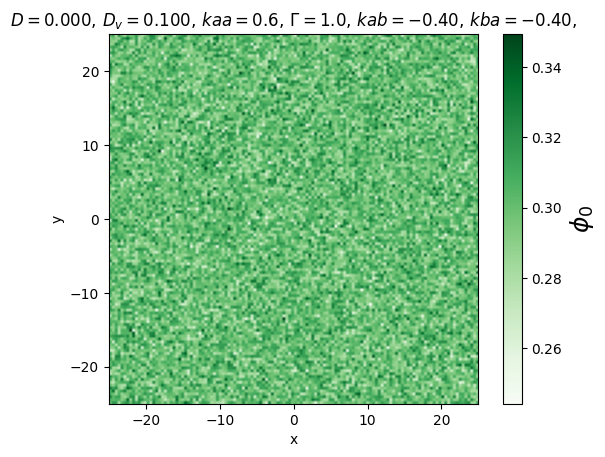

In [15]:
ep=-1
phi0 = 1 - phi_run[0] - phi_run[1]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi0[ep], cmap = 'Greens', aspect='equal', origin='lower', extent=[-Lx/2,Lx/2,-Ly/2,Ly/2])#, vmin=0, vmax=1)
plt.title(title)
plt.xlabel("x")
plt.ylabel("y")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\phi_0$",size=18)
# plt.savefig("fhd_plots/phi0_segregating_Vitelli.pdf")
plt.show()


In [20]:
np.sum(np.abs(phi0[0]-phi0[-1]))

np.float64(5.510555900478664e-11)

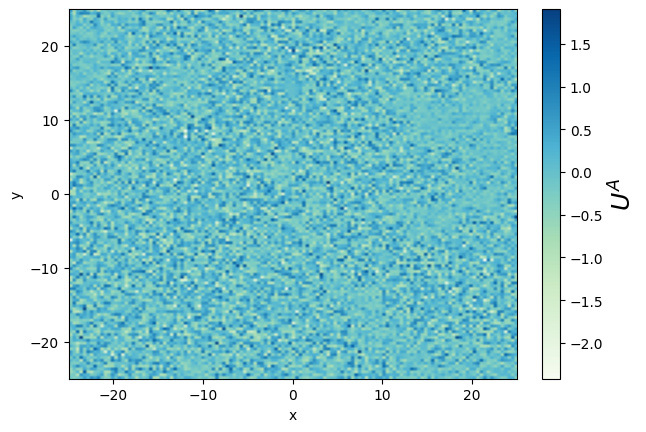

In [29]:
phi_end = phi_run[:,-1]
pi = np.einsum("ab, bij -> aij", param['kappa'],phi_end)
Gammaterm = np.einsum("ab, bij -> aij", param['Gamma'], sim_2d.lapl(phi_end))
U = pi + Gammaterm

work = sim_2d._ensure_work(phi.dtype)

phi0 = work["phi0"]

U = sim_2d.utility_from_lap(phi, work["lap_phi"], param, work)


im =plt.imshow(U[0], cmap = 'GnBu', aspect='auto', origin='lower', 
               extent=[-Lx/2,Lx/2,-Ly/2,Ly/2])
# plt.title(title)
plt.xlabel("x")
plt.ylabel("y")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$U^A$",size=18)
# plt.savefig("fhd_plots/integrating_tanh_noisy_reactions.pdf")
plt.show()


# Power Spectrum

In [62]:
param

{'D': array([0.1, 0.1]),
 'kappa': array([[0, 0],
        [0, 0]]),
 'Gamma': array([[1., 0.],
        [0., 1.]]),
 'D_v': 0.01,
 'beta': 10,
 'h': 0.01}

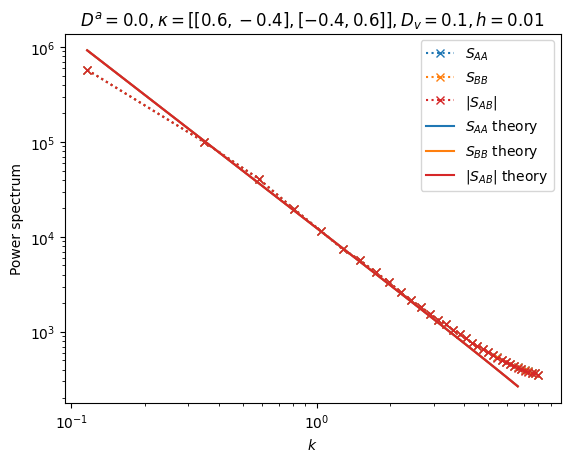

In [17]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from structure_factor import *

def fit_amplitude_logspace(theory, data):
    """
    Fit a multiplicative amplitude amp in log-space:
        log(data) ~ log(amp) + log(theory)
    """
    valid = (
        np.isfinite(theory) & np.isfinite(data) &
        (theory > 0) & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    log_amp = np.mean(np.log(data[valid]) - np.log(theory[valid]))
    return np.exp(log_amp)


averaging_bp = 200
k_bins, power_spectra, G_AB = fhd.power_spectrum(phi_run[:,:,:,:], sim_2d.L, num_bins= 50, bp = averaging_bp, centered = True)
# param['h'] = 0.01

S_AA_theory = np.zeros(len(k_bins))
S_AB_theory = np.zeros(len(k_bins))
S_BB_theory = np.zeros(len(k_bins))

param_sf = param.copy()
param_sf["D"] = np.ones(2)*1e-4
for i, k in enumerate(k_bins):
    structure_factors = structure_factor(k,phi_run[0,averaging_bp:,:].mean(), phi_run[1,averaging_bp:,:].mean(), param_sf)
    S_AA_theory[i] = structure_factors[0,0]
    S_AB_theory[i] = structure_factors[0,1]
    S_BB_theory[i] = structure_factors[1,1]


k_interp = np.linspace(k_bins.min(), k_bins.max(), 1000)  # 1000 points for smooth interpolation
interpolate_func = interp1d(k_bins, power_spectra[0], kind='cubic', fill_value="extrapolate")
SAA_interp = interpolate_func(k_interp)

# Find the k value where the spectrum is maximal
k_max_AA = k_interp[np.argmax(SAA_interp)]

# Maximal wavenumber of annular Brillouin zone
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = k_bins <= K_cut

amp = 4e5
theory_bp = 5
theory_ep = -20
k_bins_thy = k_bins[mask][theory_bp: ]

def std_amp(amp, theory, data):
    AA = np.abs(amp*theory[0] - data[0])
    BB = np.abs(amp*theory[1] - data[1])
    AB = np.abs(amp*theory[2] - data[2])
    return np.std(np.array([AA,BB,AB]))

theory = np.array([S_AA_theory[theory_bp:theory_ep], S_BB_theory[theory_bp:theory_ep], np.abs(S_AB_theory[theory_bp:theory_ep])])
data = np.array([power_spectra[0,theory_bp:theory_ep],power_spectra[1,theory_bp:theory_ep], np.abs(G_AB[theory_bp:theory_ep])])
optamp = minimize(std_amp, amp, args = (theory, data))

# dk = k_bins[1]-k_bins[0]

amp=fit_amplitude_logspace(theory, data)
amp = optamp.x

plt.plot(k_bins[mask][:], power_spectra[0,mask][:], "x:", label = r"$S_{AA}$", color = 'tab:blue')
# plt.plot(k_max_AA, interpolate_func(k_max_AA), marker = "*", color = 'k')
plt.plot(k_bins[mask][:], power_spectra[1,mask][:], "x:", label = r"$S_{BB}$", color = 'tab:orange')
# plt.plot(k_bins[mask][1:], power_spectra[2,mask][1:], "x:", label = r"$S_{00}$", color = 'tab:green')
plt.plot(k_bins[mask][:], np.abs(G_AB)[mask][:], "x:", label = r"$|S_{AB}|$", color = 'tab:red')
plt.plot(k_bins[S_AA_theory>0][:theory_ep], amp*S_AA_theory[S_AA_theory>0][:theory_ep], '-', label = r"$S_{AA}$ theory",  color = 'tab:blue')
plt.plot(k_bins[S_BB_theory>0][:theory_ep], amp*S_BB_theory[S_BB_theory>0][:theory_ep], '-', label = r"$S_{BB}$ theory", color = 'tab:orange')
plt.plot(k_bins[S_AB_theory<0][:theory_ep], amp*np.abs(S_AB_theory[S_AB_theory<0])[:theory_ep], '-', label = r"$|S_{AB}|$ theory", color = 'tab:red')
plt.title(fr"$D^a = {param['D'][0]},  \kappa = [[{kappa[0,0]},{kappa[0,1]}],[{kappa[1,0]}, {kappa[1,1]}]] , D_v = {param['D_v']}, h = {param['h']:.2f}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k$")
plt.ylabel(r"Power spectrum")
plt.legend()
plt.tight_layout
plt.show()

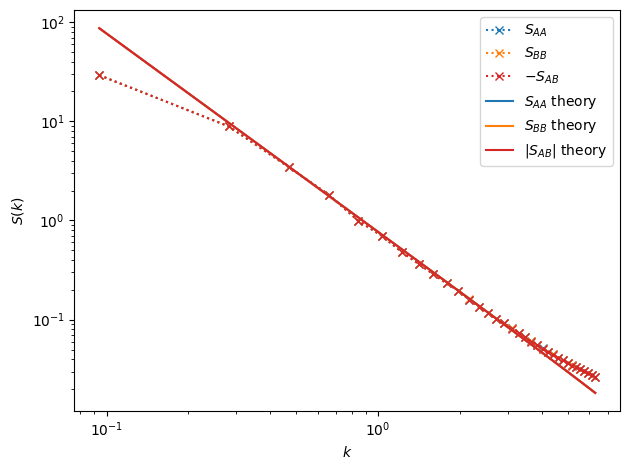

In [19]:
k, P, GAB, P2d, GAB2d, k2d = fhd.power_spectrum_dct_2d(
    phi_run,
    L=(Lx, Ly),
    bp=100,
    num_bins=60,
    use_lattice_k=False,
)

S_AA_theory = np.zeros(len(k))
S_AB_theory = np.zeros(len(k))
S_BB_theory = np.zeros(len(k))

for i, ik in enumerate(k):
    structure_factors = structure_factor(ik,phi_run[0,averaging_bp:,:].mean(), phi_run[1,averaging_bp:,:].mean(), param_sf)
    S_AA_theory[i] = structure_factors[0,0]
    S_AB_theory[i] = structure_factors[0,1]
    S_BB_theory[i] = structure_factors[1,1]

theory = np.array([S_AA_theory, S_BB_theory, np.abs(S_AB_theory)])
data = np.array([P[0],P[1], np.abs(GAB)])
K_cut = np.pi / sim_2d.dx  # or min(pi/dx, pi/dy)
mask = k <= 0.8*K_cut

plt.figure()

plt.loglog(k[mask], P[0][mask], "x:", label=r"$S_{AA}$")
plt.loglog(k[mask], P[1][mask], "x:", label=r"$S_{BB}$")
# plt.loglog(k[mask], P[2][mask], "x:", label=r"$S_{00}$")
plt.loglog(k[mask], -GAB[mask], "x:", label=r"$-S_{AB}$", color = 'tab:red')

bp = 5
ep = -40
amp=fit_amplitude_logspace(theory[:,bp:ep], data[:,bp:ep])
optamp = minimize(std_amp, amp, args = (theory, data))
# amp=optamp.x
plt.plot(k[S_AA_theory>0][mask], amp*S_AA_theory[S_AA_theory>0][mask], '-', label = r"$S_{AA}$ theory",  color = 'tab:blue')
plt.plot(k[S_BB_theory>0][mask], amp*S_BB_theory[S_BB_theory>0][mask], '-', label = r"$S_{BB}$ theory", color = 'tab:orange')
plt.plot(k[S_AB_theory<0][mask], amp*np.abs(S_AB_theory[S_AB_theory<0])[mask], '-', label = r"$|S_{AB}|$ theory", color = 'tab:red')


plt.xlabel(r"$k$")
plt.ylabel(r"$S(k)$")
plt.legend()
plt.tight_layout()

# Kmean cluster size

In [20]:
def kmean(power_spectrum, k_bins):
    Z = np.sum(power_spectrum)
    kmean = np.sum(k_bins*power_spectrum)
    return kmean/Z

frames = phi_run.shape[1]
mean_k = []

for t in range(frames):
    k_bins, power_spectra, G_AB = fhd.power_spectrum(phi_run[:,t:t+1], (Lx, Ly), num_bins=60, averaged = False, centered = True)
    mean_k.append(kmean(power_spectra[1],k_bins))

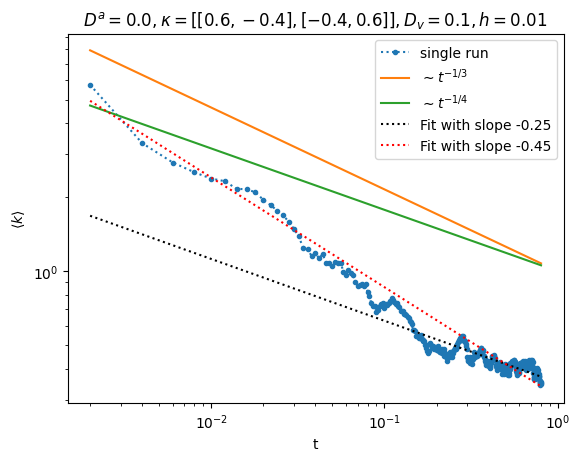

In [21]:
from scipy.stats import linregress
t = np.arange(1,frames+1,1)*dt

x = np.log(t)
y = np.log(mean_k)

res_early = linregress(x[1:20],y[1:20])

res = linregress(x[50:],y[50:])

slope = res.slope
a = np.exp(res.intercept)

slope_early = res_early.slope
a_early = np.exp(res_early.intercept)

# kappa = kappas[reg_idx]
inv_kmean = 1/np.array(mean_k)
plt.loglog(t,mean_k, '.:', label = "single run")
plt.xlabel("t")
plt.title(fr"$D^a = {param['D'][0]},  \kappa = [[{kappa[0,0]:.1f},{kappa[0,1]:.1f}],[{kappa[1,0]:.1f},{kappa[1,1]:.1f}]], D_v = {param['D_v']}, h = {param['h']}$")
plt.ylabel(r"$\langle k \rangle$")
plt.loglog(t, t**(-1/3) , label = r"$\sim t^{-1/3}$")
plt.loglog(t, t**(-1/4) , label = r"$\sim t^{-1/4}$")
plt.loglog(t, a*t**slope, ":k", label = rf"Fit with slope {slope:.2f}")
plt.loglog(t, a_early*t**slope_early, ":r", label = rf"Fit with slope {slope_early:.2f}")
plt.legend()
plt.show()

# Size of interfaces

In [22]:
def voter_interface_density(phi_run, eps=1e-14):
    """
    Interface-density diagnostic used by Dornic, Chate & Munoz.

    Parameters
    ----------
    phi_run : ndarray, shape (2, nframes, Nx, Ny)
        phi_run[0] = rho_A
        phi_run[1] = rho_B

    Returns
    -------
    rho_I : ndarray, shape (nframes,)
        rho_I(t) = 1 - <m(r,t) m(r+e,t)>,
        averaged over x- and y-nearest-neighbor bonds.
    """

    rho_A = phi_run[0]
    rho_B = phi_run[1]

    n = rho_A + rho_B

    # Voter composition / magnetization field in [-1, 1].
    # For pure voter with n=1 this is simply rho_A - rho_B.
    m = np.divide(
        rho_A - rho_B,
        n,
        out=np.zeros_like(rho_A),
        where=n > eps,
    )

    # Nearest-neighbor correlations in the two lattice directions.
    Cx = np.mean(
        m * np.roll(m, -1, axis=1),
        axis=(1, 2),
    )

    Cy = np.mean(
        m * np.roll(m, -1, axis=2),
        axis=(1, 2),
    )

    C_nn = 0.5 * (Cx + Cy)

    return 1.0 - C_nn

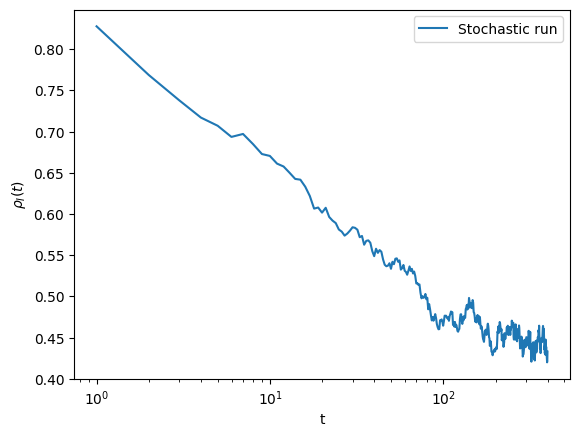

In [23]:
rho_I = voter_interface_density(phi_run)

times = np.arange(len(rho_I)) * nsteps * dt / frames

plt.semilogx(times[1:], rho_I[1:], label = "Stochastic run")
# plt.plot(times[2:],reg_res.slope**(-1)*np.log(times[2:])**(-1), ":k", label = r"$1/\ln(t)$")
plt.xlabel("t")
plt.ylabel(r"$\rho_I(t)$")
plt.legend()
plt.show()

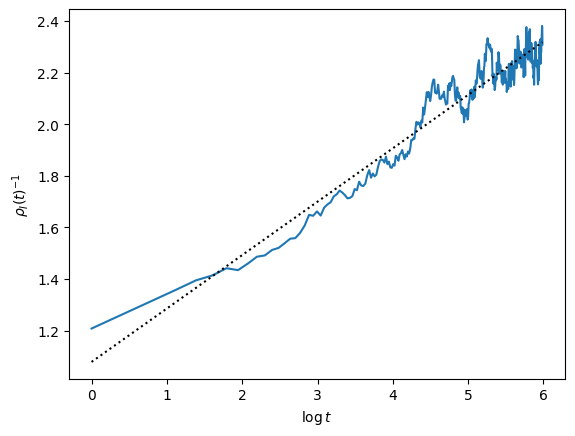

In [26]:
bp = 1
x = np.log(times[bp:])
y = 1.0 / rho_I[bp:]
reg_res = linregress(x, y)


plt.plot(np.log(times[1:]), 1.0 / rho_I[1:])
plt.plot(np.log(times[bp:]), reg_res.slope*np.log(times[bp:])+ reg_res.intercept, ":k")
plt.xlabel(r"$\log t$")
plt.ylabel(r"$\rho_I(t)^{-1}$")
plt.show()

# Animation

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 1000.0  # Set limit to 100MB, for example



# Sample data for demonstration
t = phi_run.shape[1]  # Number of time steps


# Create figure and axis
fig, ax = plt.subplots(figsize=(4,4), dpi=180)
line_phi = []
# colors = ['C0', 'C1', 'C2']
# labels = [r'$\phi_a$', r'$\phi_b$', r'$\phi_0$']

# Initialize the plot lines
# for a in range(2):
ln = ax.imshow(phi_run[0,0]-phi_run[1,0], cmap = 'RdBu', aspect='equal', origin='upper', extent=[-Lx/2,Lx/2,-Ly/2,Ly/2], vmin=-1.0, vmax=1.0)
line_phi.append(ln)

# phi0 =  1-phi_run[:,0].sum(axis=0)
# ln, = ax.plot(x, phi0, lw =2, color = colors[2], label = labels[2], marker = '.')
# line_phi.append(ln)

# ax.set_ylim([0,1])
ax.set_xlabel('x')
ax.set_ylabel('y')
# ax.legend(loc = "upper right")

# Title with parameters
# title = fr"$D = {D},\, \kappa aa = {kappa_aa:.1f},\, \kappa ab = {kappa_ab:.1f},\, \kappa ba = {kappa_ba:.1f},\, \Gamma = {Gamma}, \, b={b}, \, d={d} $"
# plt.title(title)
# plt.title(fr"$D = {D[0]},\, \kappa aa = {kappa_aa:.1f},\, \kappa ab = {kappa_ab:.1f},\, \kappa ba = {kappa_ba:.1f},\, \Gamma = { Gamma[0,0]}, \, D_v = {D_v} $")
cbar = fig.colorbar(ln, fraction=0.046)
cbar.set_label(r"$\phi_a - \phi_b$",size=18)
# fig.tight_layout

# Update function for animation
def update(frame):
    # for a in range(2):
        # line_phi[a].set_data(x, phi_run[a, frame])
    line_phi[0].set_data(phi_run[0,frame]-phi_run[1,frame])
    return line_phi

# Create animation
ani = animation.FuncAnimation(fig, update, frames=t, blit=True, interval = 42)

# Save animation as GIF
ani.save(f'gifs/stochastic_Voter.gif', writer='pillow')
HTML(ani.to_jshtml())


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 1000.0

t = phi_run.shape[1]  # Number of time steps
lx, ly = L

def make_rgb(frame):
    phi_a = phi_run[0, frame]
    phi_b = phi_run[1, frame]
    phi_0 = 1.0 - phi_a - phi_b

    # Optional safety against tiny numerical excursions outside [0, 1]
    phi_a = np.clip(phi_a, 0, 1)
    phi_b = np.clip(phi_b, 0, 1)
    phi_0 = np.clip(phi_0, 0, 1)

    # Last dimension corresponds to [R, G, B]
    rgb = np.stack(
        [phi_a, phi_b, phi_0],
        axis=-1
    )

    return rgb


# Create figure and axis
fig, ax = plt.subplots(figsize=(4, 4), dpi=170)

# Initial RGB image
rgb0 = make_rgb(0)

ln = ax.imshow(
    rgb0,
    aspect='equal',
    origin='upper',
    extent=[-lx/2, lx/2, -ly/2, ly/2]
)

ax.set_xlabel('x')
ax.set_ylabel('y')

# Optional legend explaining the RGB channels
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', label=r'$\phi_a$'),
    Patch(facecolor='green', label=r'$\phi_b$'),
    Patch(facecolor='blue', label=r'$\phi_0$')
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    framealpha=0.8
)


def update(frame):
    ln.set_data(make_rgb(frame))
    return [ln]


ani = animation.FuncAnimation(
    fig,
    update,
    frames=t,
    blit=True,
    interval=42
)

ani.save(
    'gifs/test_run_segregating_FD_RGB.gif',
    writer='pillow'
)

HTML(ani.to_jshtml())